# VEST operational-space atlas (Tier A)

The conference figure set (2026-10-12). VAFT reconstructs the equilibrium and the kinetic state as a
pipeline. This notebook places those states on literature operational-space projections, and
colours them with the stability, transport and kinetic layers built on top.

**Population.** Only the #1331 Tier A shots, and only their **good** and **admissible** EFIT slices
(preset `statistical_891`; the counts are printed below). An unreconstructible slice never
appears. Every point carries two labels:
- the EFIT quality label: filled marker = `good`, open marker = `admissible`;
- the lineage: `magnetics`, or `electron_kinetic` (Thomson pressure with Ti = Te).

**State key.** The key is Lane K's State key contract v1 (#1454): `(shot, time_efit_s, efit_lineage)`.
The layers are joined exactly on that key, with time as integer microseconds, never by index. Each
join prints how many states it matched, so a failed join cannot pass for missing data.

**Inputs.** The atlas tables are read from `$VAFT_ATLAS_DIR`. On vestserver that is
`~/runs/campaign/atlas`; elsewhere it is an rsync of it.

| file | lane | contents |
|---|---|---|
| `lane_v/efit_base.csv` | V (#1456) | operational-space coordinates per state, computed by VAFT from the row's own EFIT product |
| `v1/state.csv` | K (#1454) | labels, Thomson match, R_p = p_EFIT / p_e,TS |
| `confinement/table.csv` | D (#1490) | line-averaged $\\bar n_e$ from the Thomson profile along the $z = 0$ chord inside the LCFS (`vest_confinement._line_average_density_z0`), and $P_{loss} = P_{OH} - dW/dt$ |
| `stability/atlas_n.csv` | N (#1448) | per state and n: DCON ideal W_t (full and truncated edge), RDCON/STRIDE classical Δ′ |
| `transport/radial_summary.csv` | T (#1453) | per state: TGLF ion-scale growth rate, electron-dominated fraction of surfaces, NEO share of the ion heat flux (Ti = Te assumed) |

A layer that is not present is reported as *not available*. It is never imputed.

**Boundaries.** Literature boundaries come from `vaft.formula.boundaries` through the canonical
projections of #1425 and #1422. A line is drawn only on its own quantities. A $q_\psi$ boundary is
never drawn on $q_{95}$, and the renderer warns when VEST lies outside a boundary's fitted range,
which it often does at aspect ratio ~1.3.

In [ ]:
%matplotlib inline
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft
from vaft.diagram._op_space import get_projection
from vaft.plot.operational_space import operational_space_population

ATLAS = Path(os.environ.get("VAFT_ATLAS_DIR", "atlas")).expanduser()
print("vaft", vaft.__version__, "| atlas:", ATLAS.name, "| exists:", ATLAS.is_dir())

vaft 0.7.1 | atlas: atlas | exists: True


## Load and join the layers

In [ ]:
KEY = ["shot", "time_us", "efit_lineage"]
LINEAGE = {"magnetics-only": "magnetics", "electron-kinetic": "electron_kinetic"}   # provisional spellings (T, N)


def _keyed(df):
    df = df.copy()
    df["shot"] = df["shot"].astype(int)
    df["time_us"] = (df["time_efit_s"].astype(float) * 1e6).round().astype(int)
    df["efit_lineage"] = df["efit_lineage"].replace(LINEAGE)
    if "efit_label" in df and "efit_quality" not in df:
        df = df.rename(columns={"efit_label": "efit_quality"})
    return df


def read_layer(*parts):
    path = ATLAS.joinpath(*parts)
    files = sorted(path.glob("*.csv")) if path.is_dir() else ([path] if path.is_file() else [])
    if not files:
        return None, f"not available ({'/'.join(parts)} absent)"
    return pd.concat([_keyed(pd.read_csv(f)) for f in files], ignore_index=True), f"{len(files)} file(s)"


base, base_note = read_layer("lane_v", "efit_base.csv")
kin, kin_note = read_layer("v1", "state.csv")
assert base is not None, "the Lane V base table is required: run workflow/operational_space_atlas/build_efit_base.py"
display(base["base_status"].value_counts().rename("base rows").to_frame())   # nothing is dropped unseen
base = base[base["base_status"] == "valid"]
assert set(base["efit_quality"]) <= {"good", "admissible"}, "only good and admissible slices belong in the atlas"

table = base.copy()
def join(left, right, columns, layer):
    # left join on the state key; report how many states found a row, so a failed join is visible
    right = right[KEY + list(columns)]
    out = left.drop(columns=[c for c in columns if c in left]).merge(right, on=KEY, how="left",
                                                                      validate="one_to_one", indicator=True)
    matched = int((out.pop("_merge") == "both").sum())
    print(f"{layer}: {matched} of {len(left)} states matched; {len(right) - matched} layer rows unused")
    return out


if kin is not None:
    table = join(table, kin, ["r_sum", "r_w", "ts_status"], "kinetic state (K)")
conf, conf_note = read_layer("confinement", "table.csv")
if conf is not None:
    table = join(table, conf, ["n_e_line_avg_m3", "p_loss_W"], "confinement (D)")
    # derived only through VAFT: Hugill coordinates and the registered Greenwald density, no restated coefficient
    from vaft.formula import boundaries as B
    ne19 = table["n_e_line_avg_m3"] / 1e19
    b_geo = table["b0_t"] * table["r_reference_m"] / table["major_radius_geo_m"]
    ok = ne19.notna()
    table["murakami_parameter"] = np.nan
    table.loc[ok, "murakami_parameter"] = B.hugill_coordinates(
        ne19[ok].to_numpy(), table.loc[ok, "major_radius_geo_m"].to_numpy(), b_geo[ok].to_numpy(),
        table.loc[ok, "minor_radius_m"].to_numpy(), table.loc[ok, "area_elongation"].to_numpy(),
        table.loc[ok, "plasma_current_ma"].to_numpy())[0]
    n_gw = B.boundary_value(B.get_boundary("greenwald"), plasma_current=table["plasma_current_ma"].to_numpy(),
                            minor_radius=table["minor_radius_m"].to_numpy())
    table["greenwald_fraction"] = ne19 / n_gw
    table["loss_power"] = table["p_loss_W"] / 1e6
from vaft.formula import boundaries as B
# machine quantities under the boundary registry's names; B_T at R_geo from the field at the reference radius
table["plasma_current"] = table["plasma_current_ma"]
table["minor_radius"] = table["minor_radius_m"]
table["major_radius"] = table["major_radius_geo_m"]
table["toroidal_field"] = table["b0_t"] * table["r_reference_m"] / table["major_radius_geo_m"]
table["aspect_ratio"] = table["major_radius"] / table["minor_radius"]
# Freidberg's kink safety factor, Eq. (13.160) (not kink_safety_factor, #1524)
table["kink_safety_factor_elliptic"] = B.kink_coordinates(table["minor_radius"], table["major_radius"],
                                                          table["toroidal_field"], table["elongation"],
                                                          table["plasma_current"])
if "n_e_line_avg_m3" in table:
    table["line_average_density"] = table["n_e_line_avg_m3"] / 1e20   # the Martin/Takizuka unit
table.attrs["units"] = {"normalized_beta": "% m T/MA", "normalized_current": "MA m^-1 T^-1", "toroidal_beta": "%",
                        "murakami_parameter": "1e19 m^-2 T^-1", "loss_power": "MW", "plasma_current": "MA",
                        "minor_radius": "m", "major_radius": "m", "toroidal_field": "T", "plasma_surface_area": "m^2",
                        "line_average_density": "1e20 m^-3"}

layers = {"EFIT base (V)": base_note, "kinetic state (K)": kin_note,
          "confinement (D)": conf_note if conf is not None else "not available"}
for name, parts in {"stability (N)": ("stability", "atlas_n.csv"), "transport (T)": ("transport", "radial_summary.csv")}.items():
    layers[name] = read_layer(*parts)[1]
display(pd.Series(layers, name="layer").to_frame())
counts = table.groupby(["efit_lineage", "efit_quality"]).size().rename("states")
display(counts.to_frame())
print(f"{len(table)} states: {counts.get(('magnetics', 'good'), 0)} good + "
      f"{counts.get(('magnetics', 'admissible'), 0)} admissible magnetics slices")

             base rows
base_status           
valid              150

kinetic state (K): 150 of 150 states matched; 0 layer rows unused
confinement (D): 133 of 150 states matched; 0 layer rows unused


                       layer
EFIT base (V)      1 file(s)
kinetic state (K)  1 file(s)
confinement (D)    1 file(s)
stability (N)      1 file(s)
transport (T)      1 file(s)

                               states
efit_lineage     efit_quality        
electron_kinetic admissible        16
                 good               1
magnetics        admissible       115
                 good              18

150 states: 18 good + 115 admissible magnetics slices


## Coordinates

The base table names its columns by the quantity identity of `vaft.formula.boundaries`:

| column | quantity |
|---|---|
| `internal_inductance_li3` | $l_i(3) = 2\\int B_p^2\\,dV/(\\mu_0^2 I_p^2 R_0)$, DD value (`update_equilibrium_global_quantities_beta_li`) |
| `normalized_beta` | $\\beta_N$ [% m T/MA], DD value from the same routine |
| `edge_safety_factor_95`, `edge_safety_factor` | $q_{95}$ and the boundary $q_\\psi$ |
| `toroidal_beta`, `normalized_current` | $\\beta_T$ [%] and $I_p/(aB_0)$ |

Before #1477, the DD routine returned up to 10× $l_i$ and 4× $\\beta_N$ on many Tier A slices
(#1462). Every row is therefore cross-checked against two independent paths: a grid integral of
$B_p^2$ (`li3_grid_integral`) and `derive_global_descriptors` (`beta_normal_descriptors`). The
table below shows the result.

In [ ]:
display(table["li_beta_crosscheck"].value_counts().rename("l_i / beta_N cross-check").to_frame())
cols = ["internal_inductance_li3", "normalized_beta", "edge_safety_factor_95", "edge_safety_factor",
        "toroidal_beta", "normalized_current", "r_w"]
display(table.groupby("efit_quality")[[c for c in cols if c in table]].describe().T.round(3))

                    l_i / beta_N cross-check
li_beta_crosscheck                          
agree                                    150

efit_quality                   admissible    good
internal_inductance_li3 count     131.000  19.000
                        mean        0.530   0.533
                        std         0.121   0.096
                        min         0.349   0.373
                        25%         0.433   0.485
                        50%         0.508   0.513
                        75%         0.608   0.574
                        max         0.902   0.782
normalized_beta         count     131.000  19.000
                        mean        1.430   1.136
                        std         0.464   0.345
                        min         0.257   0.722
                        25%         1.122   0.903
                        50%         1.454   1.018
                        75%         1.732   1.263
                        max         2.422   1.873
edge_safety_factor_95   count     131.000  19.000
                        mean        7.457   8.701
                        std         1.851   1.670


## Figure 1: global stability projections

$\beta_N$–$l_i$ and the Troyon plane carry the registered Troyon limit ($\beta_N \le 2.76$, an
$n = 1$, no-wall ideal-MHD result at conventional aspect ratio). $q_{95}$–$l_i$ has no registered
boundary on exactly these quantities, so it shows data only.

states with q_psi > 10 (beyond the Wesson figure): 62 | states with R_W > 6 (clipped colour): 3


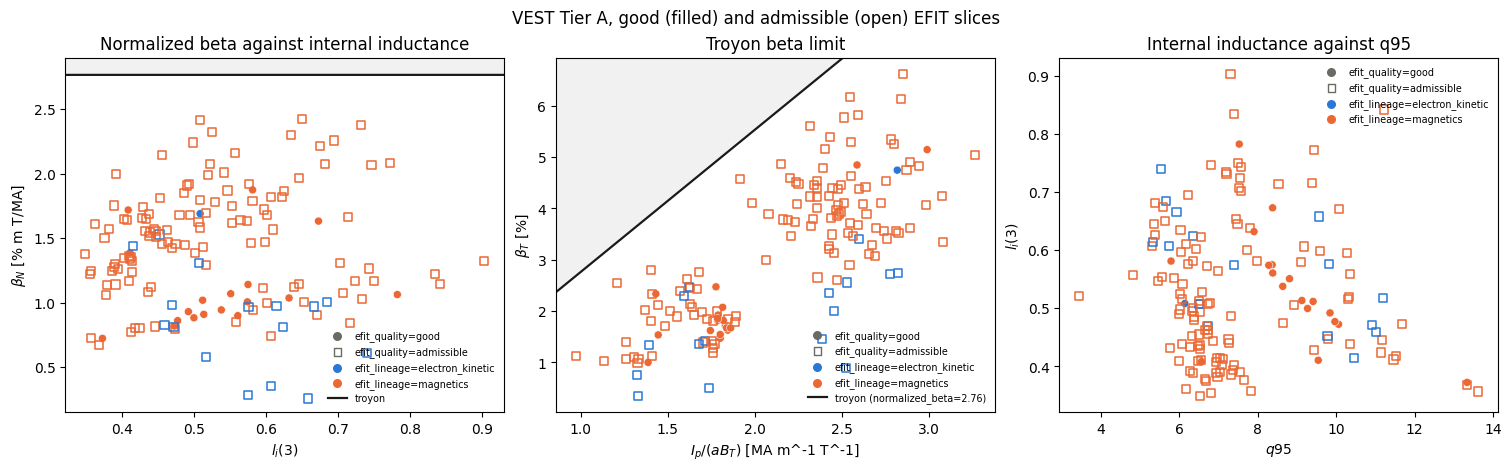

In [ ]:
STYLE = dict(marker="efit_quality", hollow=["admissible"])
WESSON_SPAN = dict(x_range=(0.0, 18.0), y_range=(0.0, 2.0))   # the whole Fig. 6 boundary plus the VEST q_psi range
RW = dict(color_limits=(0.0, 6.0))                             # R_W beyond 6 is drawn at the top of the scale
print("states with q_psi > 10 (beyond the Wesson figure):", int((table["edge_safety_factor"] > 10).sum()),
      "| states with R_W > 6 (clipped colour):", int((table.get("r_w", pd.Series(dtype=float)) > 6).sum()))
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    operational_space_population(table, "beta_n_li", color="efit_lineage", ax=axs[0], **STYLE)
    operational_space_population(table, "troyon", color="efit_lineage", ax=axs[1], **STYLE)
    operational_space_population(table, "q95_li", color="efit_lineage", ax=axs[2], **STYLE)
    fig.suptitle("VEST Tier A, good (filled) and admissible (open) EFIT slices")
    plt.show()
for w in caught:
    print("note:", w.message)

## Figure 2: the $l_i$–$q_\psi$ plane against the JET empirical boundaries

This uses the Wesson 1989 Fig. 6 boundaries: the kink and double-tearing region below, and
density-limit disruptions above. VEST sits at higher $q_\psi$ and lower aspect ratio than the JET
data the boundary was drawn from. The renderer flags the states outside its $q_\psi$ range, and the
lines are a reference, not a VEST limit. States beyond $q_\psi = 10$ have no boundary at all: the JET
figure stops there. The theoretical Cheng 1987 domain uses a cylinder's $q(a)$
and $l_i$, which VEST does not have, so it is shown only as the reference diagram.

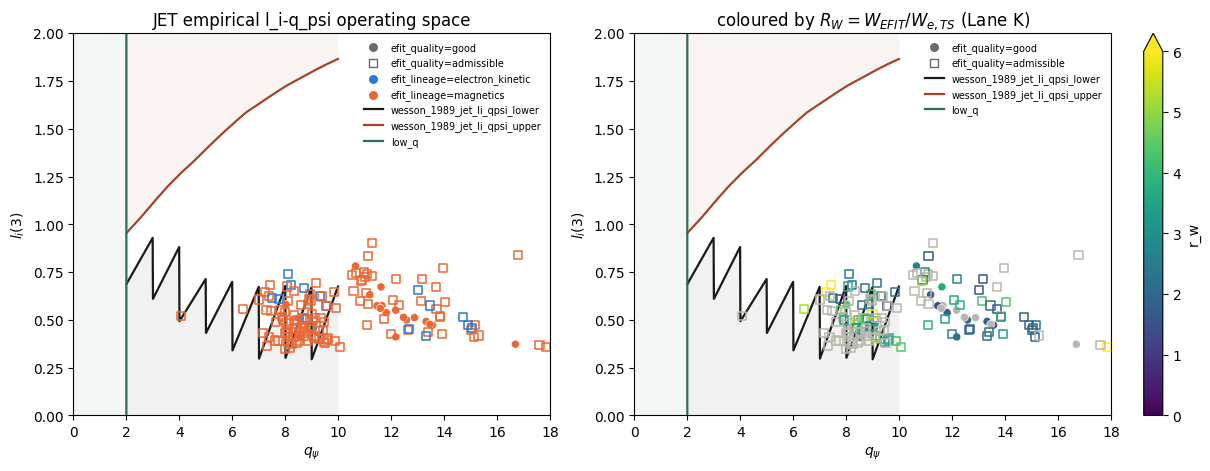

note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect

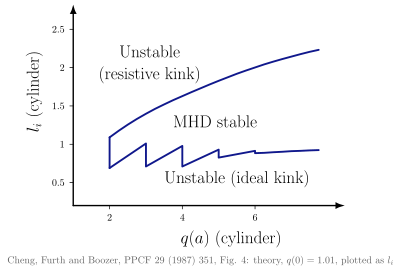

In [ ]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
    operational_space_population(table, "li_qa_wesson", color="efit_lineage", ax=axs[0], **STYLE, **WESSON_SPAN)
    if "r_w" in table:
        operational_space_population(table, "li_qa_wesson", color="r_w", ax=axs[1], **STYLE, **WESSON_SPAN, **RW)
        axs[1].set_title("coloured by $R_W = W_{EFIT}/W_{e,TS}$ (Lane K)")
    plt.show()
for w in caught:
    print("note:", w.message)
vaft.diagram.li_qa(reference="cheng_1987")

## Figure 3: the kinetic layer, how much pressure the magnetics carry

$R_W$ (Lane K, #1430) is the ratio of the EFIT pressure integral to the Thomson electron pressure
integral over the matched span. For a magnetics-only fit, $R_W \gg 2$ (with Ti = Te) means the
magnetics carry pressure that the electrons cannot account for.

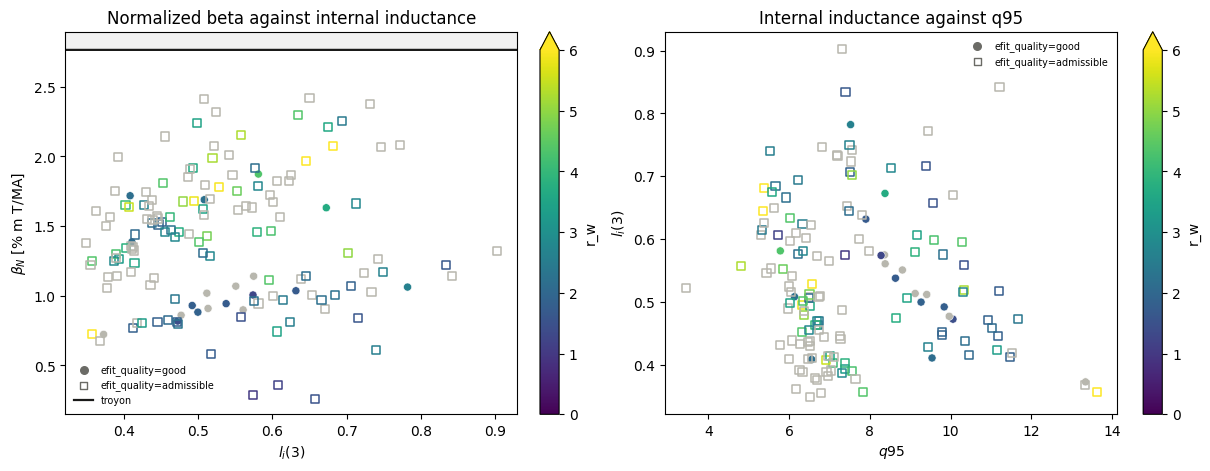

                               count  mean   std   min   25%   50%   75%  \
efit_lineage     efit_quality                                              
electron_kinetic admissible     16.0  2.00  0.46  0.99  1.83  2.09  2.27   
                 good            1.0  2.23   NaN  2.23  2.23  2.23  2.23   
magnetics        admissible     53.0  4.54  5.54  1.50  2.64  3.54  4.38   
                 good           11.0  2.25  0.96  1.27  1.71  1.87  2.39   

                                 max  
efit_lineage     efit_quality         
electron_kinetic admissible     2.57  
                 good           2.23  
magnetics        admissible    37.41  
                 good           4.36  

In [ ]:
if "r_w" not in table or table["r_w"].notna().sum() == 0:
    print("kinetic layer: not available")
else:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
    operational_space_population(table, "beta_n_li", color="r_w", ax=axs[0], **STYLE, **RW)
    operational_space_population(table, "q95_li", color="r_w", ax=axs[1], **STYLE, **RW)
    plt.show()
    display(table.groupby(["efit_lineage", "efit_quality"])["r_w"].describe().round(2))

## Figure 4: stability and transport layers

The per-$n$ stability atlas (Lane N, #1448) and the transport atlas (Lane T, #1453) are joined on
the same key. A state with no row in a layer is drawn grey, which means *not available*, not
stable.

The stability panels apply **universal physical criteria** to the raw solver output, and attach
**numerical QA** as a separate label. Nothing is reclassified by magnitude.
- **Ideal (DCON, energy principle):** the sign of the least-stable normalized eigenvalue $W_t$.
  $W_t > 0$ is stable and $W_t < 0$ is unstable, however small. QA: the sign is *mpsi-robust* when
  the mpsi 256 and 512 runs agree, and *unresolved* when refinement changes it. Full-edge $W_t$ is
  also sensitive to the edge treatment (#141, #792), so full and truncated edge are separate panels.
- **Classical tearing drive (RDCON outer region):** $\\Delta' > 0$ at *any* rational surface,
  first and last included. QA: a surface is *two-resolution consistent* when mpsi 256 and 512 agree
  in sign and within 20 %. That threshold is a pragmatic consistency heuristic from #141, not a
  validated resolution limit. Under #939, $\\Delta' > 0$ is an outer-region drive, not a
  tearing-mode verdict, which needs an inner-layer treatment.
- One figure per $n$; RDCON and STRIDE are never mixed. Coverage targets DCON $n = 1$–$6$ and
  RDCON/STRIDE $n = 1$–$2$; the panels follow whatever $n$ the atlas holds.

$l_i(3)$ and $\\beta_N$ are the DD values after #1477, the fix of #1462. Where that routine wrote
nothing, the base table uses the independent grid-integral and descriptor values instead, and its
`li_beta_source` column says which source it used.

stability atlas: v1, criteria computed here from raw columns
stability (N), n = 1: 150 of 150 states matched; 0 layer rows unused


                        n = 1: ideal_full_edge
ideal_full_edge                               
stable (mpsi-robust)                       145
unstable (mpsi-robust)                       1
sign changes with mpsi                       4
stable (not refined)                         0
unstable (not refined)                       0
not available                                0

                        n = 1: ideal_trunc_edge
ideal_trunc_edge                               
stable (mpsi-robust)                        150
unstable (mpsi-robust)                        0
sign changes with mpsi                        0
stable (not refined)                          0
unstable (not refined)                        0
not available                                 0

                                                n = 1: rdcon_tearing_drive
rdcon_tearing_drive                                                       
Δ′ > 0 at a surface, two-resolution consistent                           6
Δ′ > 0 only where not consistent                                        90
Δ′ ≤ 0 at every rational surface                                        54
not available                                                            0

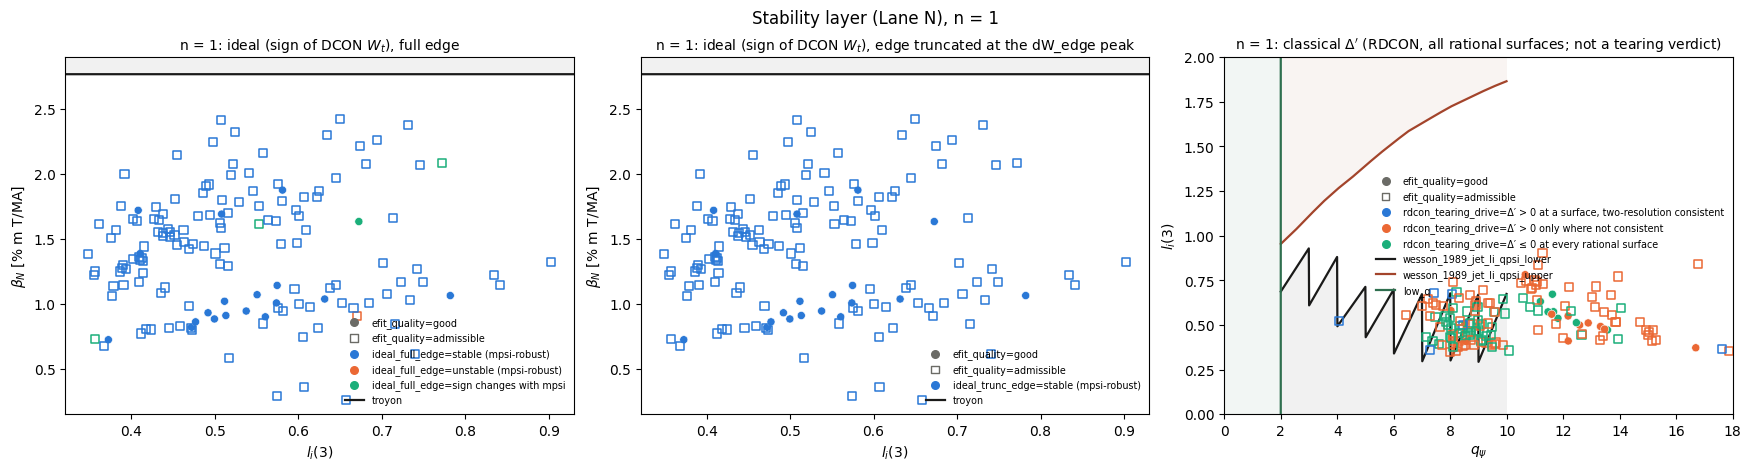

note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
stability (N), n = 2: 150 of 150 states matched; 0 layer rows unused


                        n = 2: ideal_full_edge
ideal_full_edge                               
stable (mpsi-robust)                       147
unstable (mpsi-robust)                       1
sign changes with mpsi                       2
stable (not refined)                         0
unstable (not refined)                       0
not available                                0

                        n = 2: ideal_trunc_edge
ideal_trunc_edge                               
stable (mpsi-robust)                        150
unstable (mpsi-robust)                        0
sign changes with mpsi                        0
stable (not refined)                          0
unstable (not refined)                        0
not available                                 0

                                                n = 2: rdcon_tearing_drive
rdcon_tearing_drive                                                       
Δ′ > 0 at a surface, two-resolution consistent                           5
Δ′ > 0 only where not consistent                                        87
Δ′ ≤ 0 at every rational surface                                        57
not available                                                            1

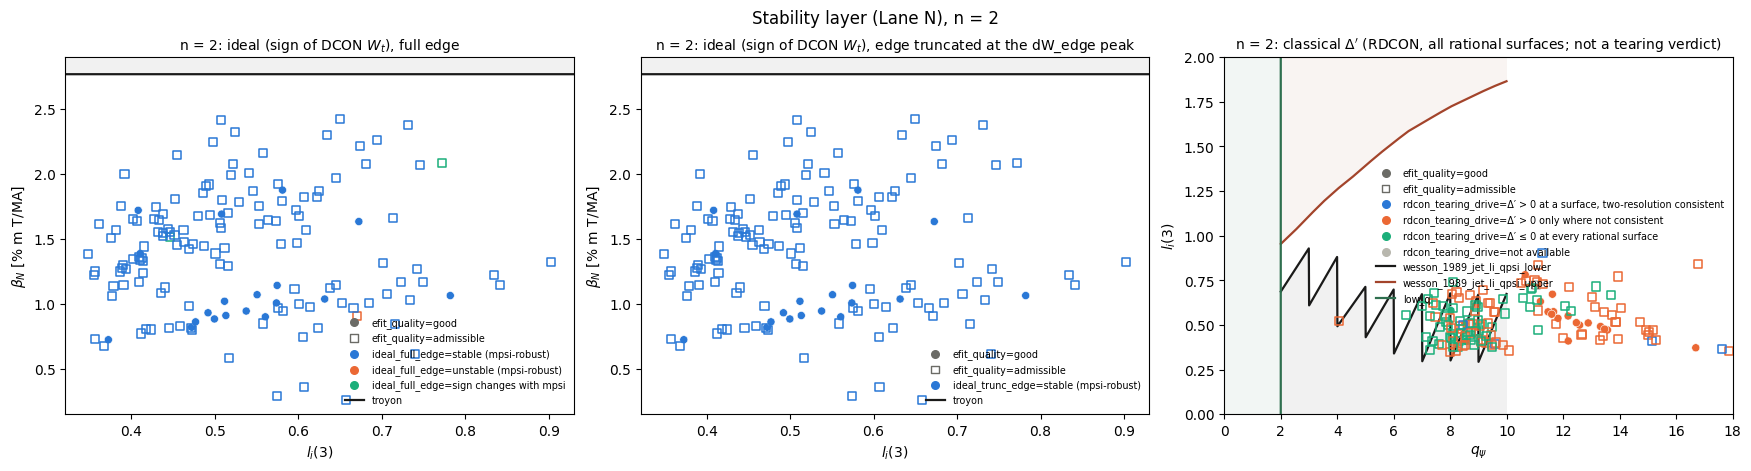

note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
transport (T): 81 of 150 states matched; 0 layer rows unused


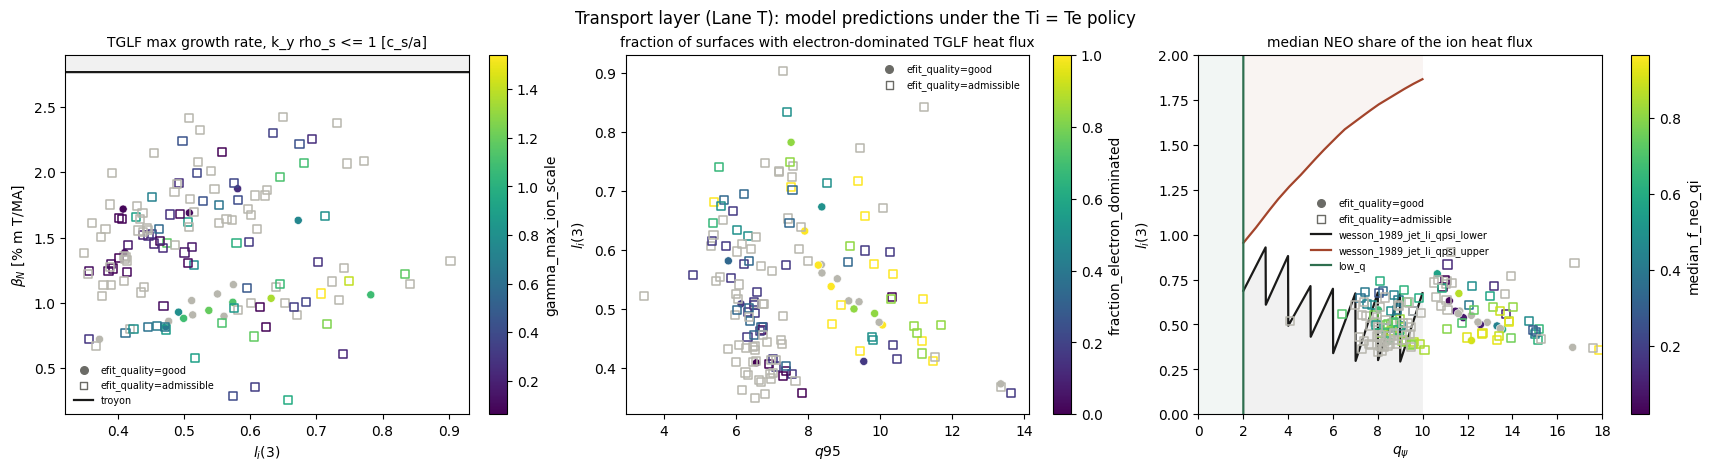

In [ ]:
def layer_column(df, candidates, layer, required=True):
    found = next((c for c in candidates if c in df.columns), None)
    if found is None and required:
        raise KeyError(f"{layer}: none of {candidates} among columns {list(df.columns)[:30]}")
    print(f"{layer}: using column {found!r}")
    return found


def flag(series):
    return series.astype(str).str.lower().isin(["true", "1", "1.0"])


stab, note = read_layer("stability", "atlas_n.csv")
surf, _ = read_layer("stability", "atlas_surfaces.csv")
if stab is None:
    print("stability layer:", note)
else:
    IDEAL = ["stable (mpsi-robust)", "unstable (mpsi-robust)", "sign changes with mpsi",
             "stable (not refined)", "unstable (not refined)", "not available"]
    TEARING = ["Δ′ > 0 at a surface, two-resolution consistent", "Δ′ > 0 only where not consistent",
               "Δ′ ≤ 0 at every rational surface", "not available"]

    def ideal_verdict(w256, w512):
        # energy principle: the sign of W_t is the criterion; refinement only qualifies confidence
        if not np.isfinite(w256):
            return "not available"
        if not np.isfinite(w512):   # the sign stands; only its mpsi check is missing
            return "stable (not refined)" if w256 > 0 else "unstable (not refined)"
        if np.sign(w512) != np.sign(w256):
            return "sign changes with mpsi"
        return "stable (mpsi-robust)" if w256 > 0 else "unstable (mpsi-robust)"

    def tearing_drive(group):
        pos = group[group["delta_prime"] > 0]
        if pos.empty:
            return TEARING[2]
        consistent = (np.sign(pos["delta_prime"]) == np.sign(pos["delta_prime_mpsi512"])) & \
                     (pos["delta_prime_relative_change"] <= 0.20)
        return TEARING[0] if consistent.any() else TEARING[1]

    V2 = "dcon_full_sign_class" in stab.columns   # Lane N atlas v2 (#1509) carries the verdicts itself
    print("stability atlas:", "v2 verdict columns" if V2 else "v1, criteria computed here from raw columns")
    SIGN = {"robust_stable": IDEAL[0], "robust_unstable": IDEAL[1], "numerically_unresolved": IDEAL[2]}

    def ideal_column(sub, edge):
        if V2:
            w = pd.to_numeric(sub[f"dcon_{edge}_256_W_t"], errors="coerce")
            not_refined = np.where(w > 0, IDEAL[3], np.where(w < 0, IDEAL[4], IDEAL[5]))
            label = sub[f"dcon_{edge}_sign_class"].map(SIGN)
            return label.where(label.notna(), pd.Series(not_refined, index=sub.index)).tolist()
        return [ideal_verdict(a, b) for a, b in zip(pd.to_numeric(sub[f"dcon_{edge}_256_W_t"], errors="coerce"),
                                                    pd.to_numeric(sub[f"dcon_{edge}_512_W_t"], errors="coerce"))]

    def drive_frame(sub, n, solver="rdcon"):
        if V2:
            drive, qa = flag(sub[f"{solver}_classical_tearing_drive"]), flag(sub[f"{solver}_classical_tearing_drive_qa"])
            known = sub[f"{solver}_classical_tearing_drive"].astype(str).str.lower().isin(["true", "false"])
            label = np.where(~known, TEARING[3], np.where(qa, TEARING[0], np.where(drive, TEARING[1], TEARING[2])))
            return sub[KEY].assign(tearing_drive=label)
        rd = surf[(surf["n_tor"] == n) & (surf["solver"] == solver)]
        return rd.groupby(KEY).apply(tearing_drive, include_groups=False).rename("tearing_drive").reset_index()

    for n in sorted(stab["n_tor"].dropna().astype(int).unique()):
        sub = stab[stab["n_tor"] == n].copy()
        for edge in ("full", "trunc"):
            sub[f"ideal_{edge}_edge"] = ideal_column(sub, edge)
        cols = ["ideal_full_edge", "ideal_trunc_edge"]
        if n in (1, 2) and (V2 or surf is not None):
            drive = drive_frame(sub, n).rename(columns={"tearing_drive": "rdcon_tearing_drive"})
            sub = sub.merge(drive, on=KEY, how="left", validate="one_to_one")
            cols.append("rdcon_tearing_drive")
        t = join(table, sub, cols, f"stability (N), n = {n}")
        for c, cats in (("ideal_full_edge", IDEAL), ("ideal_trunc_edge", IDEAL), ("rdcon_tearing_drive", TEARING)):
            if c in t:   # one category, one colour, in every figure
                t[c] = pd.Categorical(t[c].fillna("not available"), categories=cats)
        t.attrs = table.attrs
        for c in cols:   # one table per criterion: different criteria are never summed
            display(t[c].value_counts(sort=False).rename(f"n = {n}: {c}").to_frame())
        fig, axs = plt.subplots(1, len(cols), figsize=(5.8 * len(cols), 4.6), constrained_layout=True)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            operational_space_population(t, "beta_n_li", color="ideal_full_edge", ax=axs[0], **STYLE)
            operational_space_population(t, "beta_n_li", color="ideal_trunc_edge", ax=axs[1], **STYLE)
            if "rdcon_tearing_drive" in t:
                operational_space_population(t, "li_qa_wesson", color="rdcon_tearing_drive", ax=axs[2],
                                             **STYLE, **WESSON_SPAN)
        axs[0].set_title(f"n = {n}: ideal (sign of DCON $W_t$), full edge", fontsize=10)
        axs[1].set_title(f"n = {n}: ideal (sign of DCON $W_t$), edge truncated at the dW_edge peak", fontsize=10)
        if "rdcon_tearing_drive" in t:
            axs[2].set_title(f"n = {n}: classical $\\Delta'$ (RDCON, all rational surfaces; not a tearing verdict)",
                             fontsize=10)
        fig.suptitle(f"Stability layer (Lane N), n = {n}")
        plt.show()
        for message in dict.fromkeys(str(w.message) for w in caught):   # each note once
            print("note:", message)

trans, note = read_layer("transport", "radial_summary.csv")
if trans is None:
    print("transport layer:", note)
else:
    # one row per state: Lane T's radial summary over r/a = 0.3-0.8 (TGLF + NEO, Ti = Te assumed; model output)
    cols = {"gamma_max_ion_scale": "TGLF max growth rate, k_y rho_s <= 1 [c_s/a]",
            "fraction_electron_dominated": "fraction of surfaces with electron-dominated TGLF heat flux",
            "median_f_neo_qi": "median NEO share of the ion heat flux"}
    missing = [c for c in cols if c not in trans]
    if missing:
        raise KeyError(f"transport (T): missing {missing} among {list(trans.columns)}")
    t = join(table, trans, list(cols), "transport (T)")
    t.attrs = table.attrs
    fig, axs = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    for ax, (col, label), proj in zip(axs, cols.items(), ("beta_n_li", "q95_li", "li_qa_wesson")):
        extra = WESSON_SPAN if proj == "li_qa_wesson" else {}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")   # the extrapolation notes were printed with Figure 2
            operational_space_population(t, proj, color=col, ax=ax, **STYLE, **extra)
        ax.set_title(label, fontsize=10)
    fig.suptitle("Transport layer (Lane T): model predictions under the Ti = Te policy")
    plt.show()


## Figure 5: every operating limit against every stability criterion

Each figure shows one criterion on every operational-space projection that has its exact
quantities in the base table:
- the kink planes of the PPCF 2025 paper (Fig. 8): $q_*$–$I_p/aB$ and $I_p$–$\\kappa$. $q_*$ is
  Freidberg's Eq. (13.160), $2\\pi a^2\\kappa B_0/(\\mu_0 R_0 I)$. The limit $q_* \\ge (1+\\kappa)/2$
  (Eq. 13.162) is drawn at the largest $\\kappa$ in the population. $I_{max} = (2\\pi a^2 B_0/\\mu_0 R_0)\\,
  2\\kappa/(1+\\kappa)$ (Eq. 13.163) is drawn at the population-median $a$, $R_0$, $B_0$. (The paper's
  printed Eqs. 5 and 7 differ from Freidberg; its Fig. 8 lines are Eqs. 13.162–13.163, #1524);
- the Troyon plane ($\beta_T$–$I_p/aB_0$, with the registered Troyon limit);
- $\beta_N$–$l_i(3)$ (Troyon);
- $q_{95}$–$l_i(3)$ (no registered boundary on these quantities);
- the JET empirical $l_i$–$q_\psi$ plane (Wesson 1989; boundaries drawn over their fitted range,
  flagged where VEST lies outside it);
- the Hugill plane ($\bar n_e R/B_T$–$1/q_\mathrm{cyl}$, with the Greenwald and Murakami limits);
- $n/n_G$–$P_{loss}$;
- L–H access, $P_{loss}$–$\\bar n_e$ [$10^{20}\\,\\mathrm{m^{-3}}$], with Martin 2008 and Takizuka 2004
  (low-$A$ correction, $Z_{eff} = 2$ as Lane D assumes) at the population-median $B_T$, $S$, $I_p$, $a$
  and $A$. VEST lies below the fitted range of both. The Ryter low-density minimum is stated in
  $10^{19}\\,\\mathrm{m^{-3}}$, so the identity check leaves it off this axis.

The two density planes use Lane D's line-averaged density (#1490). It is the Thomson $n_e$ profile
fit, mapped on the row's own equilibrium and averaged along the $z = 0$ chord inside the LCFS. It is
a reconstructed line average, not an interferometer measurement: Thomson covers only the core
channels, so the outer part of the chord comes from the profile fit. It exists for the states with
a Thomson profile at the EFIT time. $P_{loss} = P_{OH} - dW/dt$ ($P_{rad}$ is not mapped).

The criteria are the universal ones of Figure 4: the sign of DCON $W_t$ per $n$ (full edge) with
mpsi robustness as QA; the classical $\Delta'$ drive at any RDCON rational surface for $n = 1, 2$;
and the local criteria (ballooning $C_A < 0$, Mercier $D_I > 0$, GGJ $D_R > 0$). The panels follow
whatever $n$ the atlas holds; the target is DCON $n = 1$–$6$.

**Coverage:** every projection whose quantities are available is drawn. The three density planes
hold only the states with a Thomson line average (magnetics lineage). A boundary outside its fitted
range is still drawn, and the renderer prints an extrapolation note for it.

density planes: 64 states have a Thomson line average; 63 also have P_loss
ideal, n = 1: 150 of 150 states matched; 0 layer rows unused


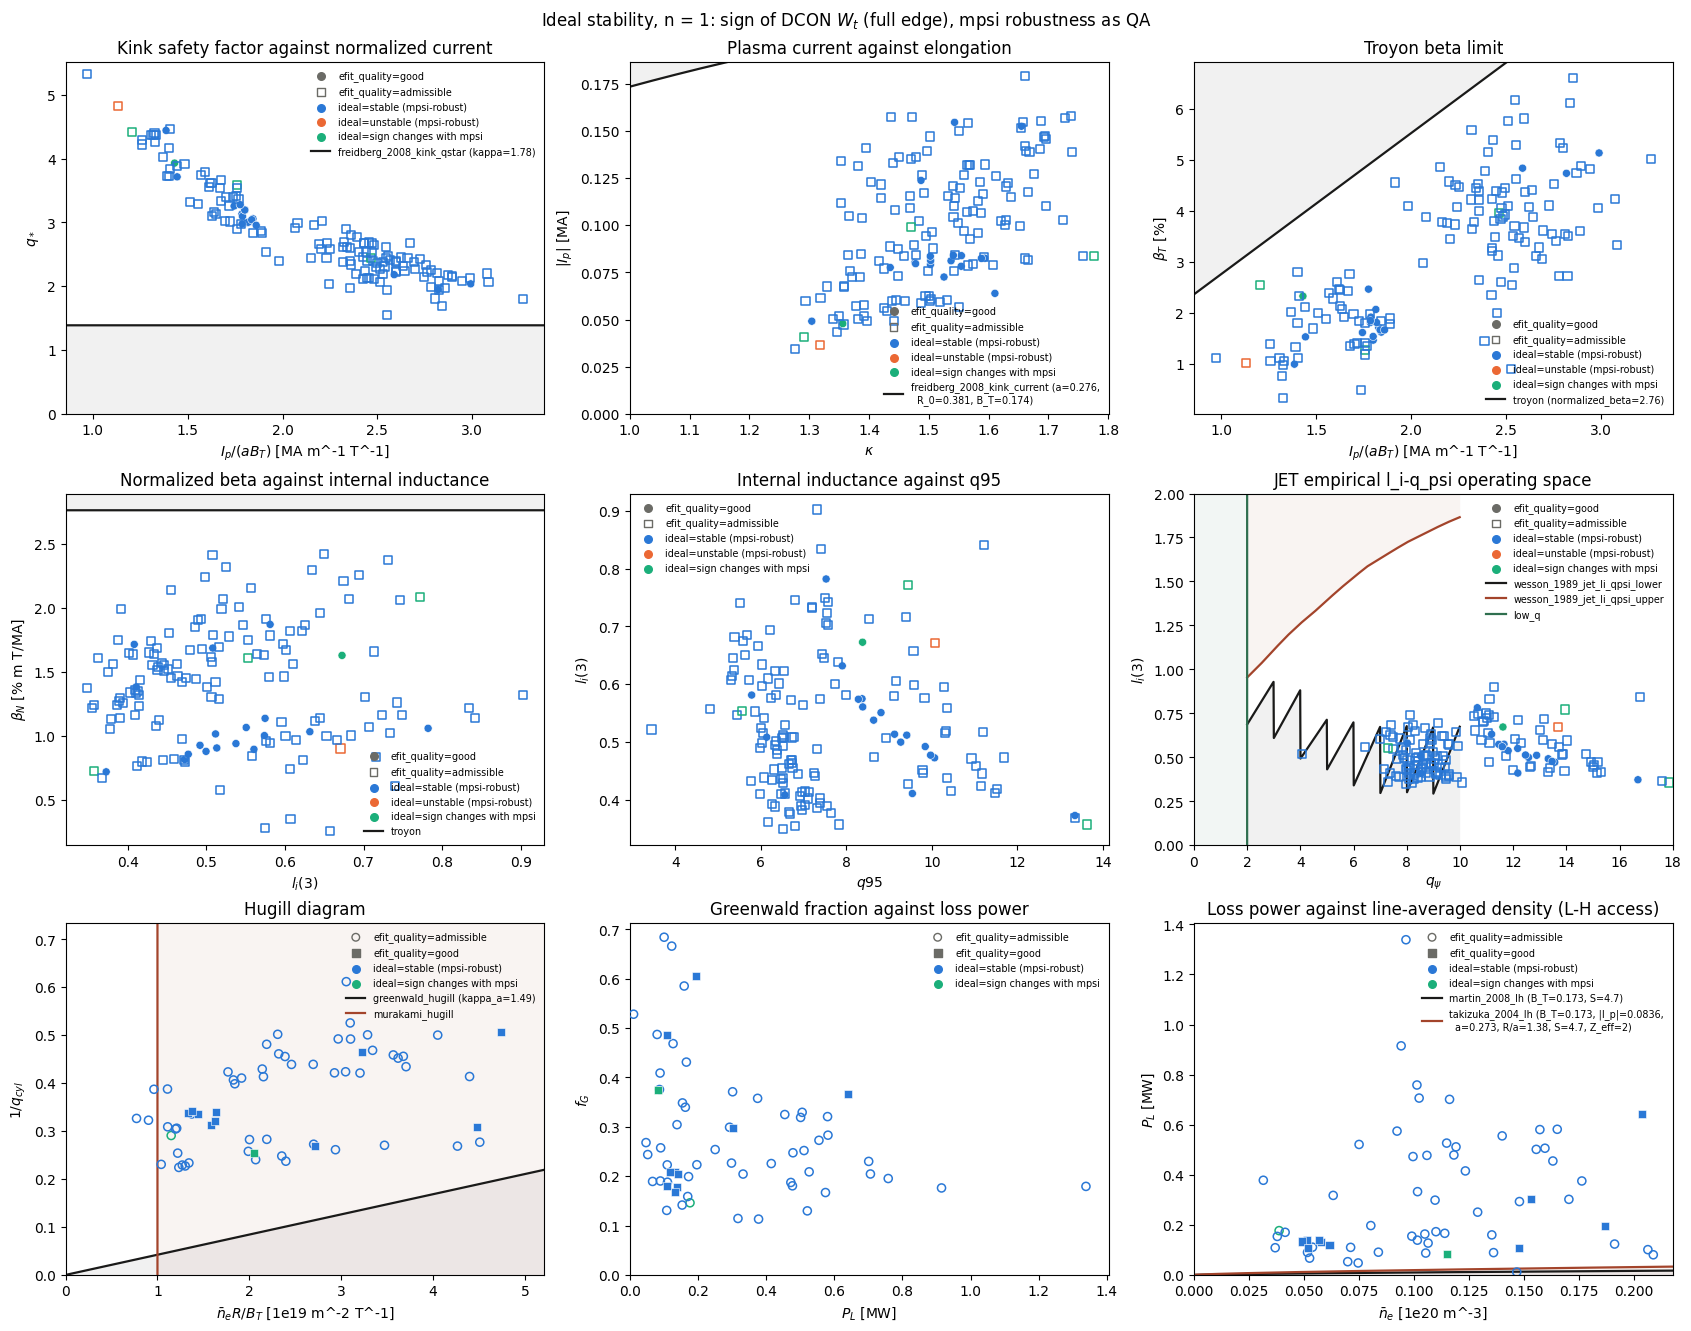

states plotted per plane: {'qstar_in': 150, 'ip_kappa': 150, 'troyon': 150, 'beta_n_li': 150, 'q95_li': 150, 'li_qa_wesson': 150, 'hugill': 64, 'greenwald_fraction_power': 63, 'lh_threshold': 63}
note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section
note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks
ide

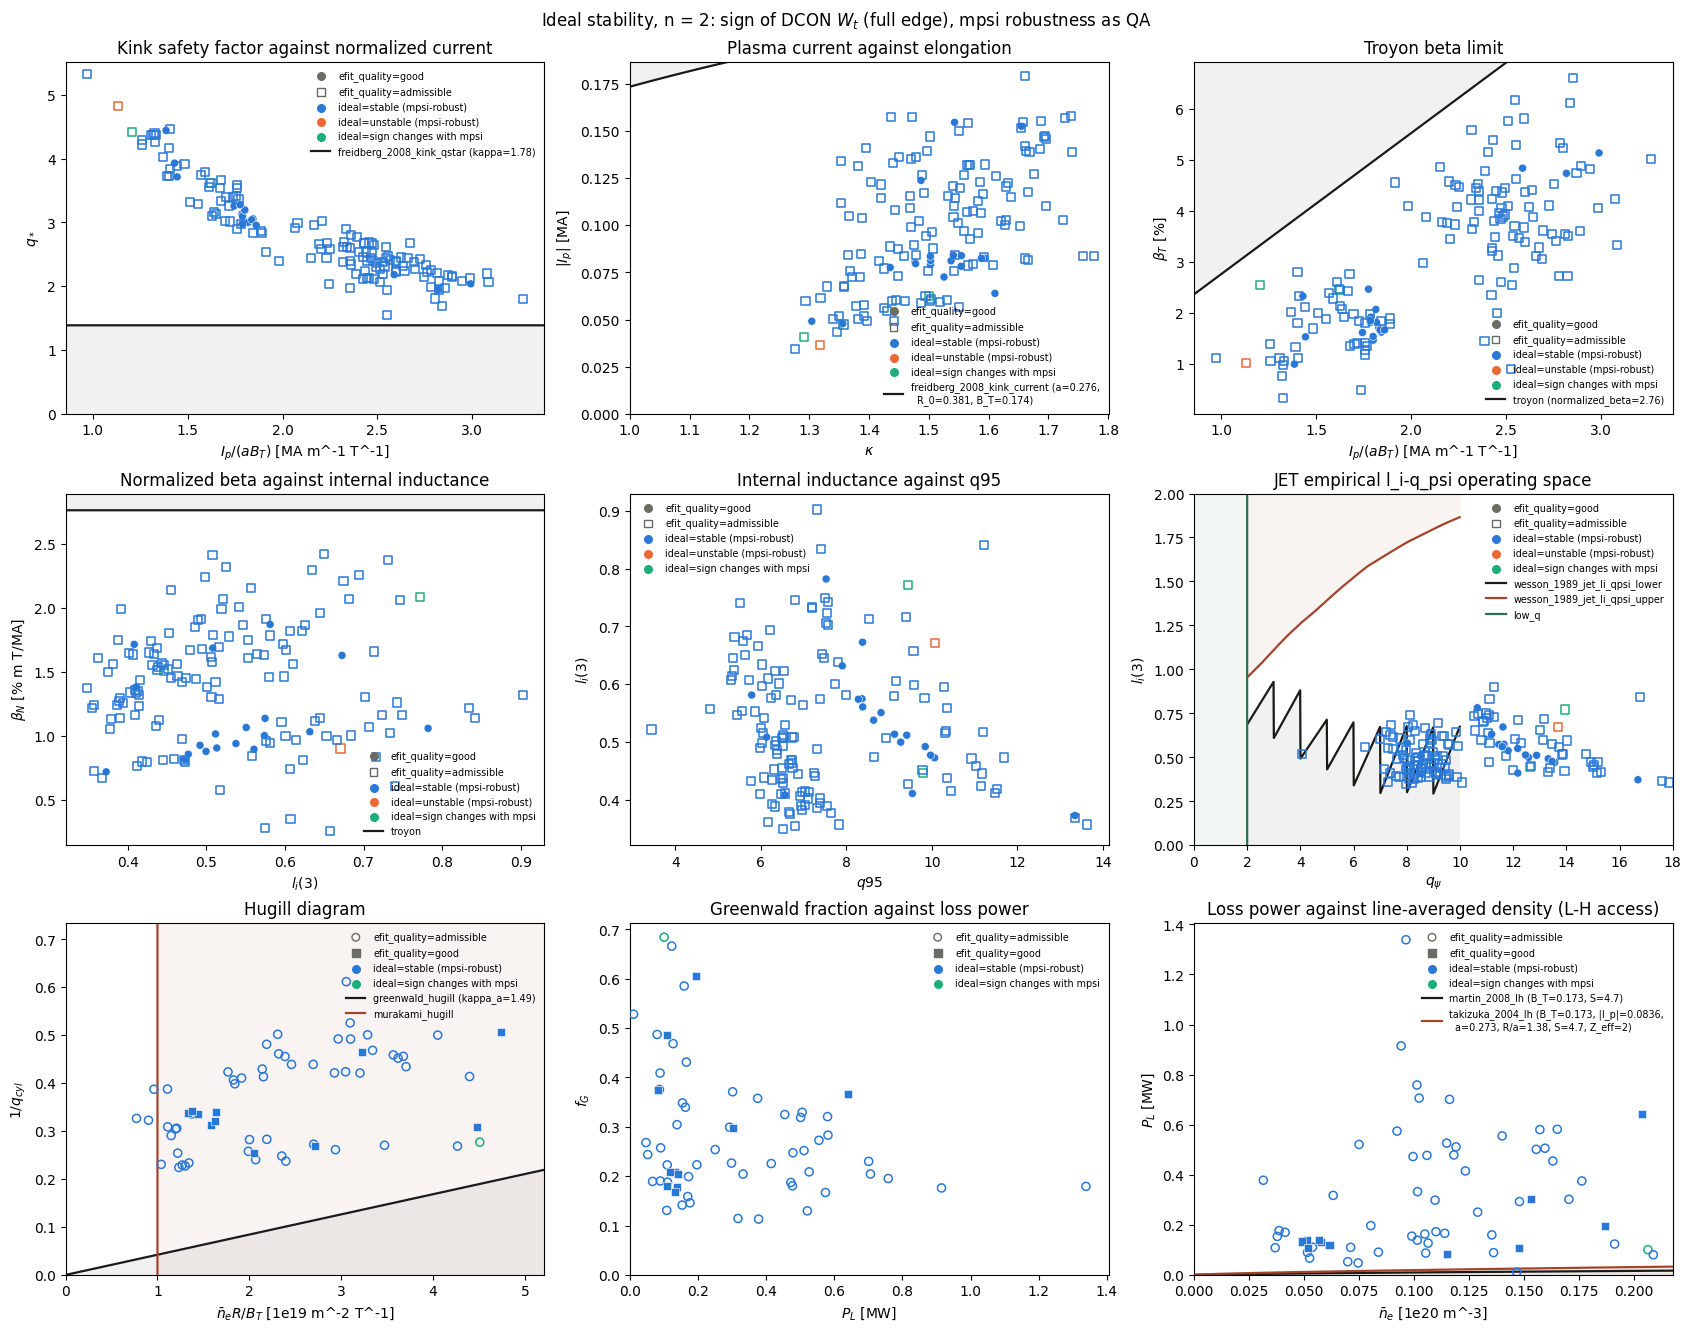

states plotted per plane: {'qstar_in': 150, 'ip_kappa': 150, 'troyon': 150, 'beta_n_li': 150, 'q95_li': 150, 'li_qa_wesson': 150, 'hugill': 64, 'greenwald_fraction_power': 63, 'lh_threshold': 63}
note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section
note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks
RDC

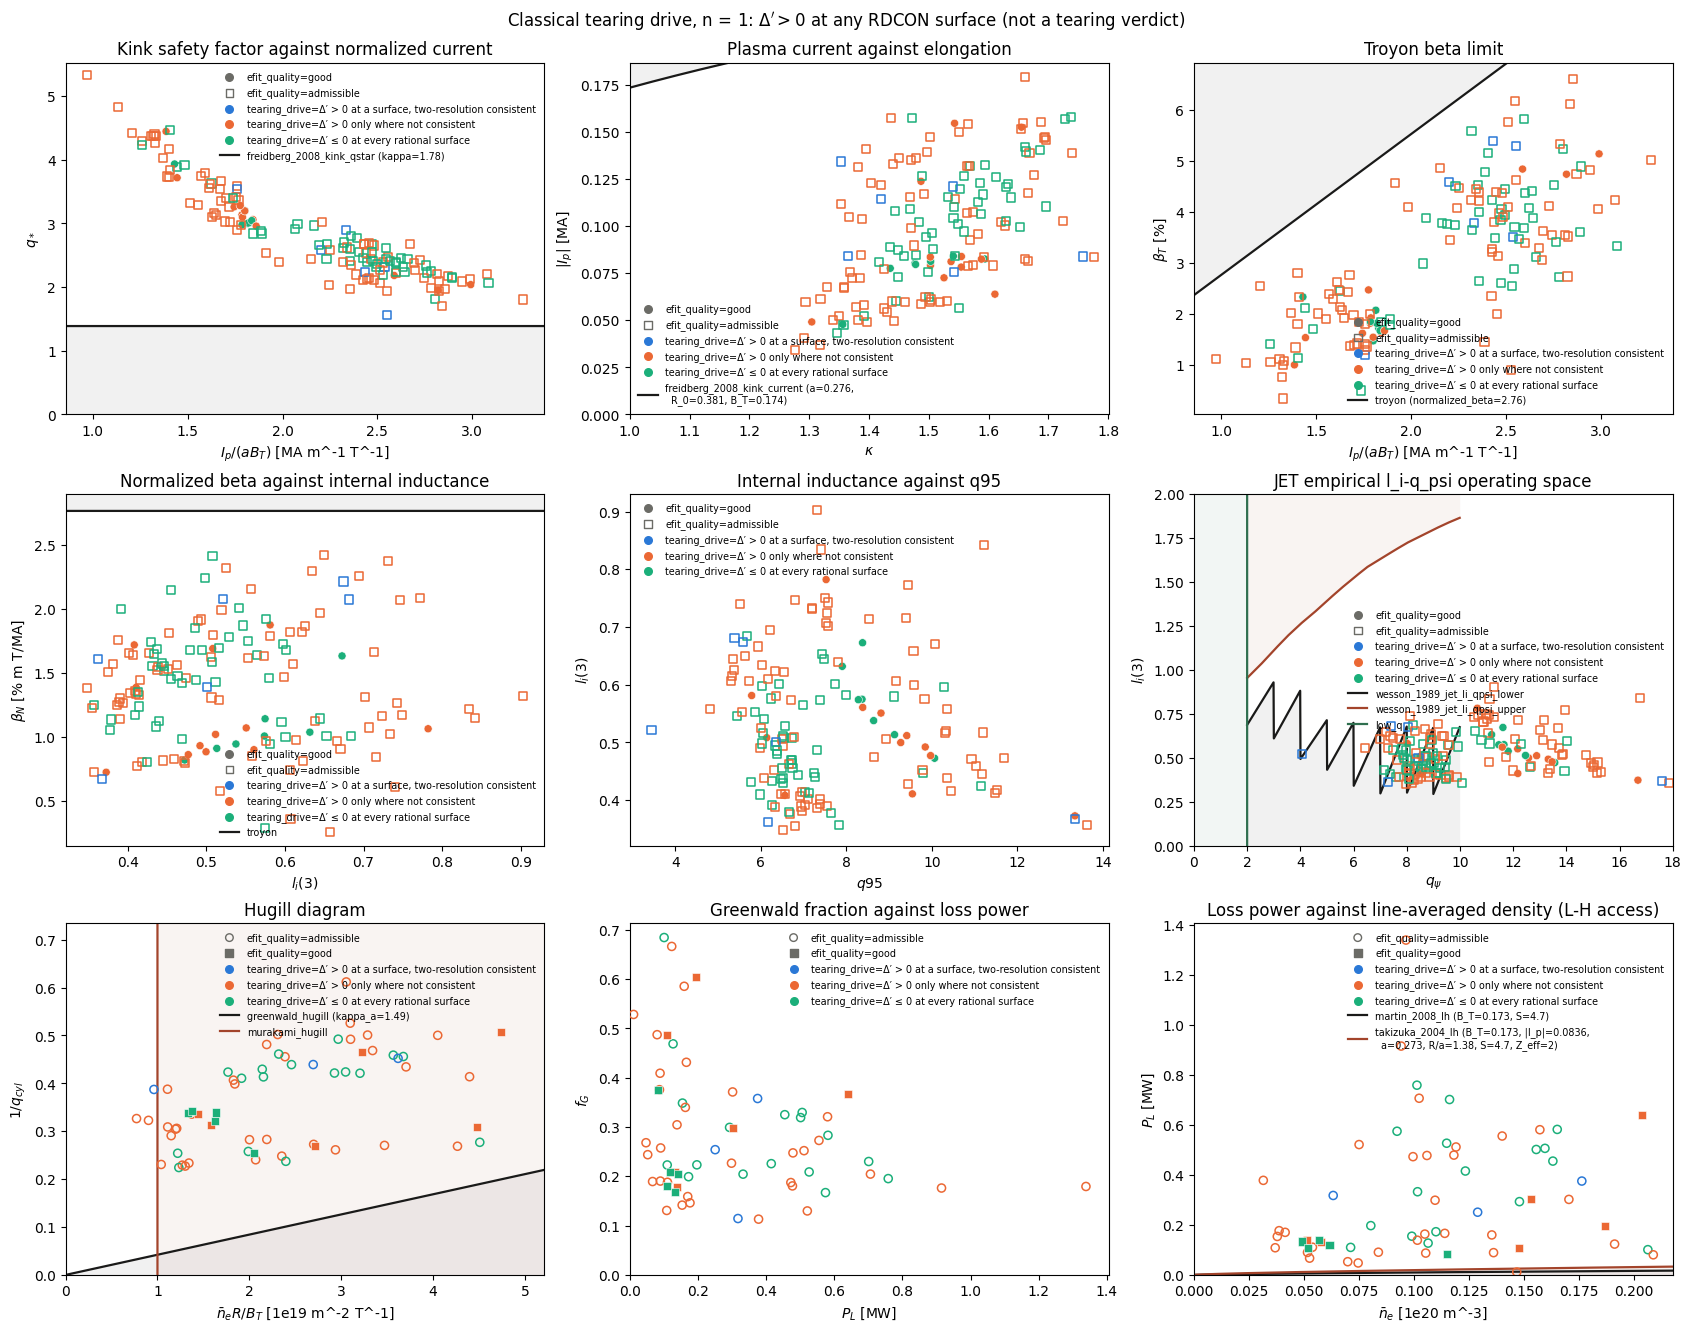

states plotted per plane: {'qstar_in': 150, 'ip_kappa': 150, 'troyon': 150, 'beta_n_li': 150, 'q95_li': 150, 'li_qa_wesson': 150, 'hugill': 64, 'greenwald_fraction_power': 63, 'lh_threshold': 63}
note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section
note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks
RDC

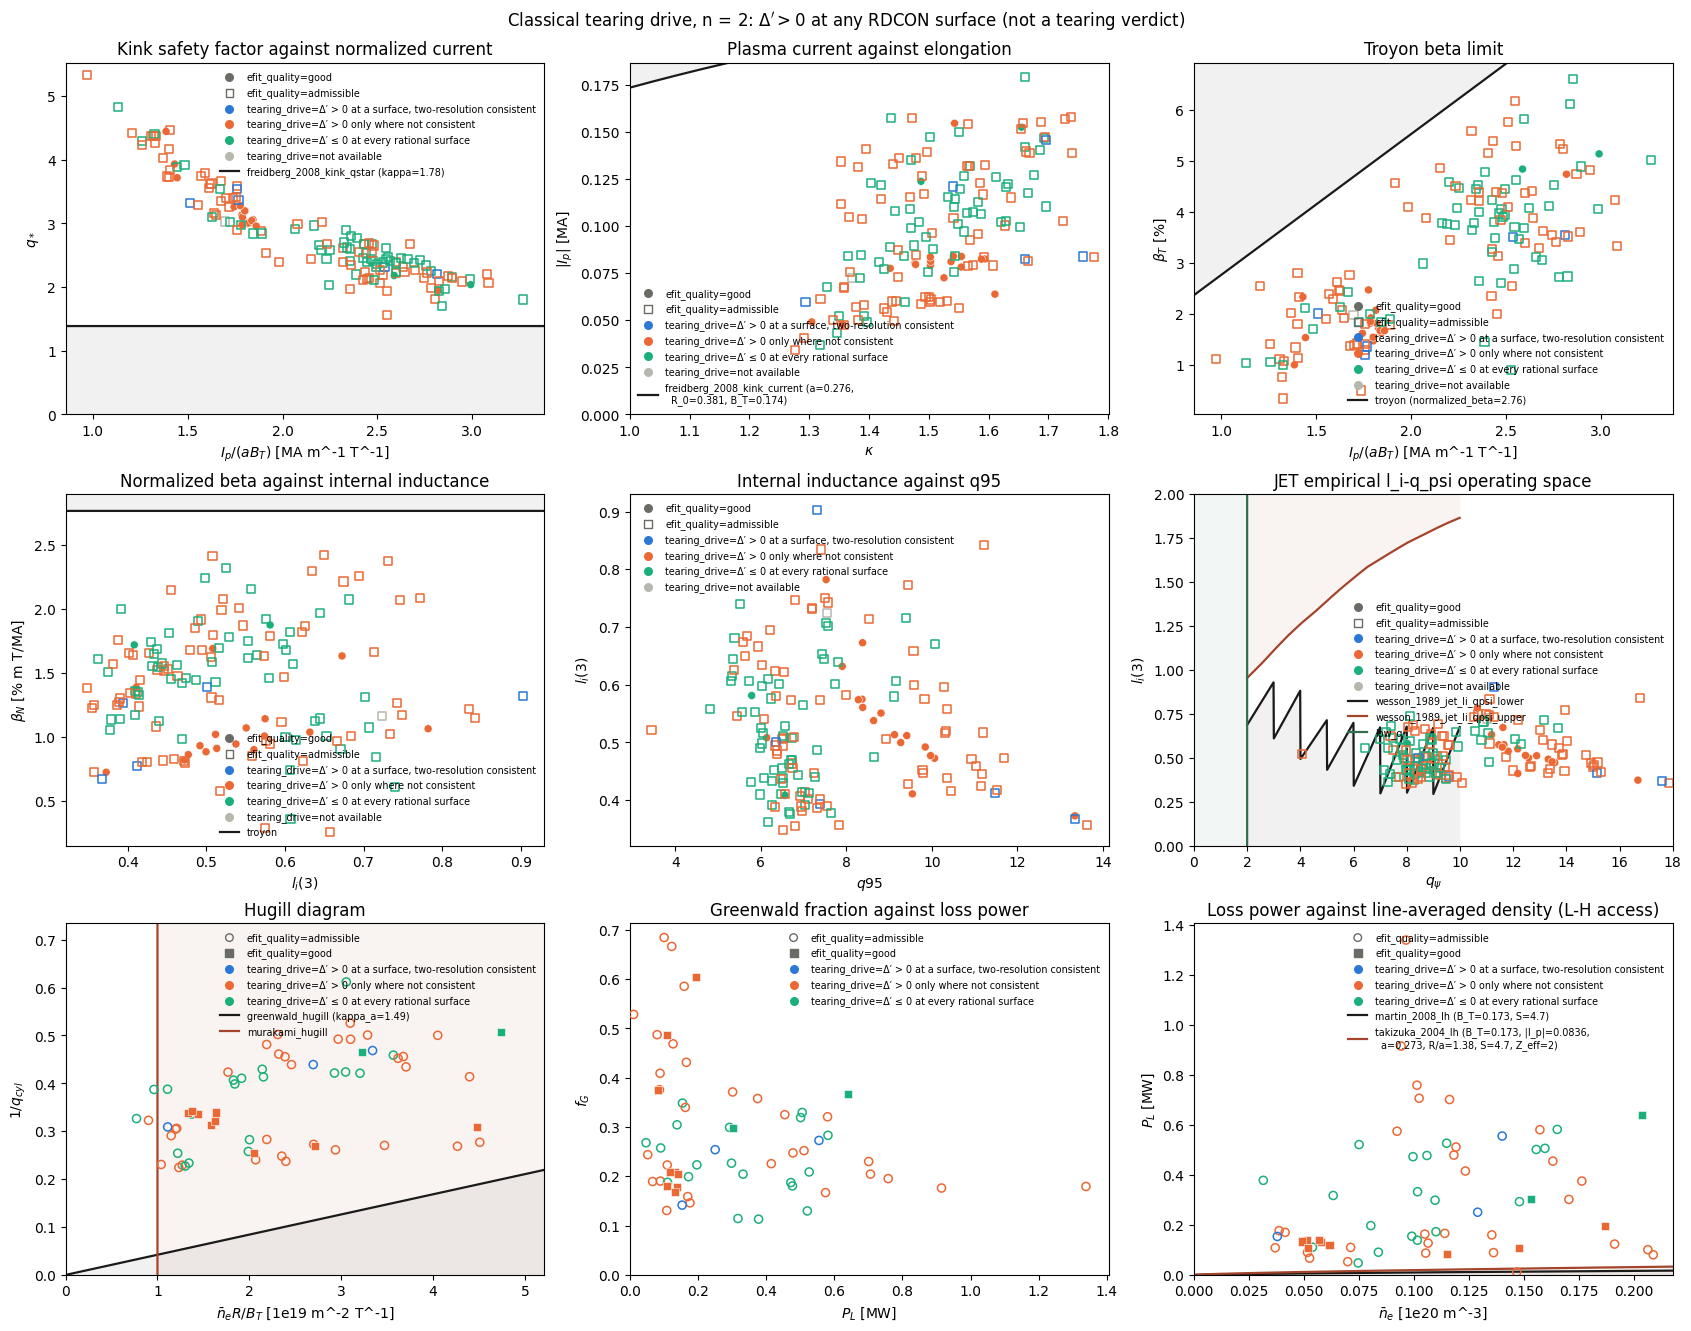

states plotted per plane: {'qstar_in': 150, 'ip_kappa': 150, 'troyon': 150, 'beta_n_li': 150, 'q95_li': 150, 'li_qa_wesson': 150, 'hugill': 64, 'greenwald_fraction_power': 63, 'lh_threshold': 63}
note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section
note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks
loc

                                                    local criteria
local                                                             
D_R > 0 (GGJ)                                                  119
none (all evaluated)                                            19
C_A < 0 (ballooning)                                             7
C_A < 0 (ballooning) + D_R > 0 (GGJ)                             4
C_A < 0 (ballooning) + D_I > 0 (Mercier) + D_R ...               1
not available                                                    0

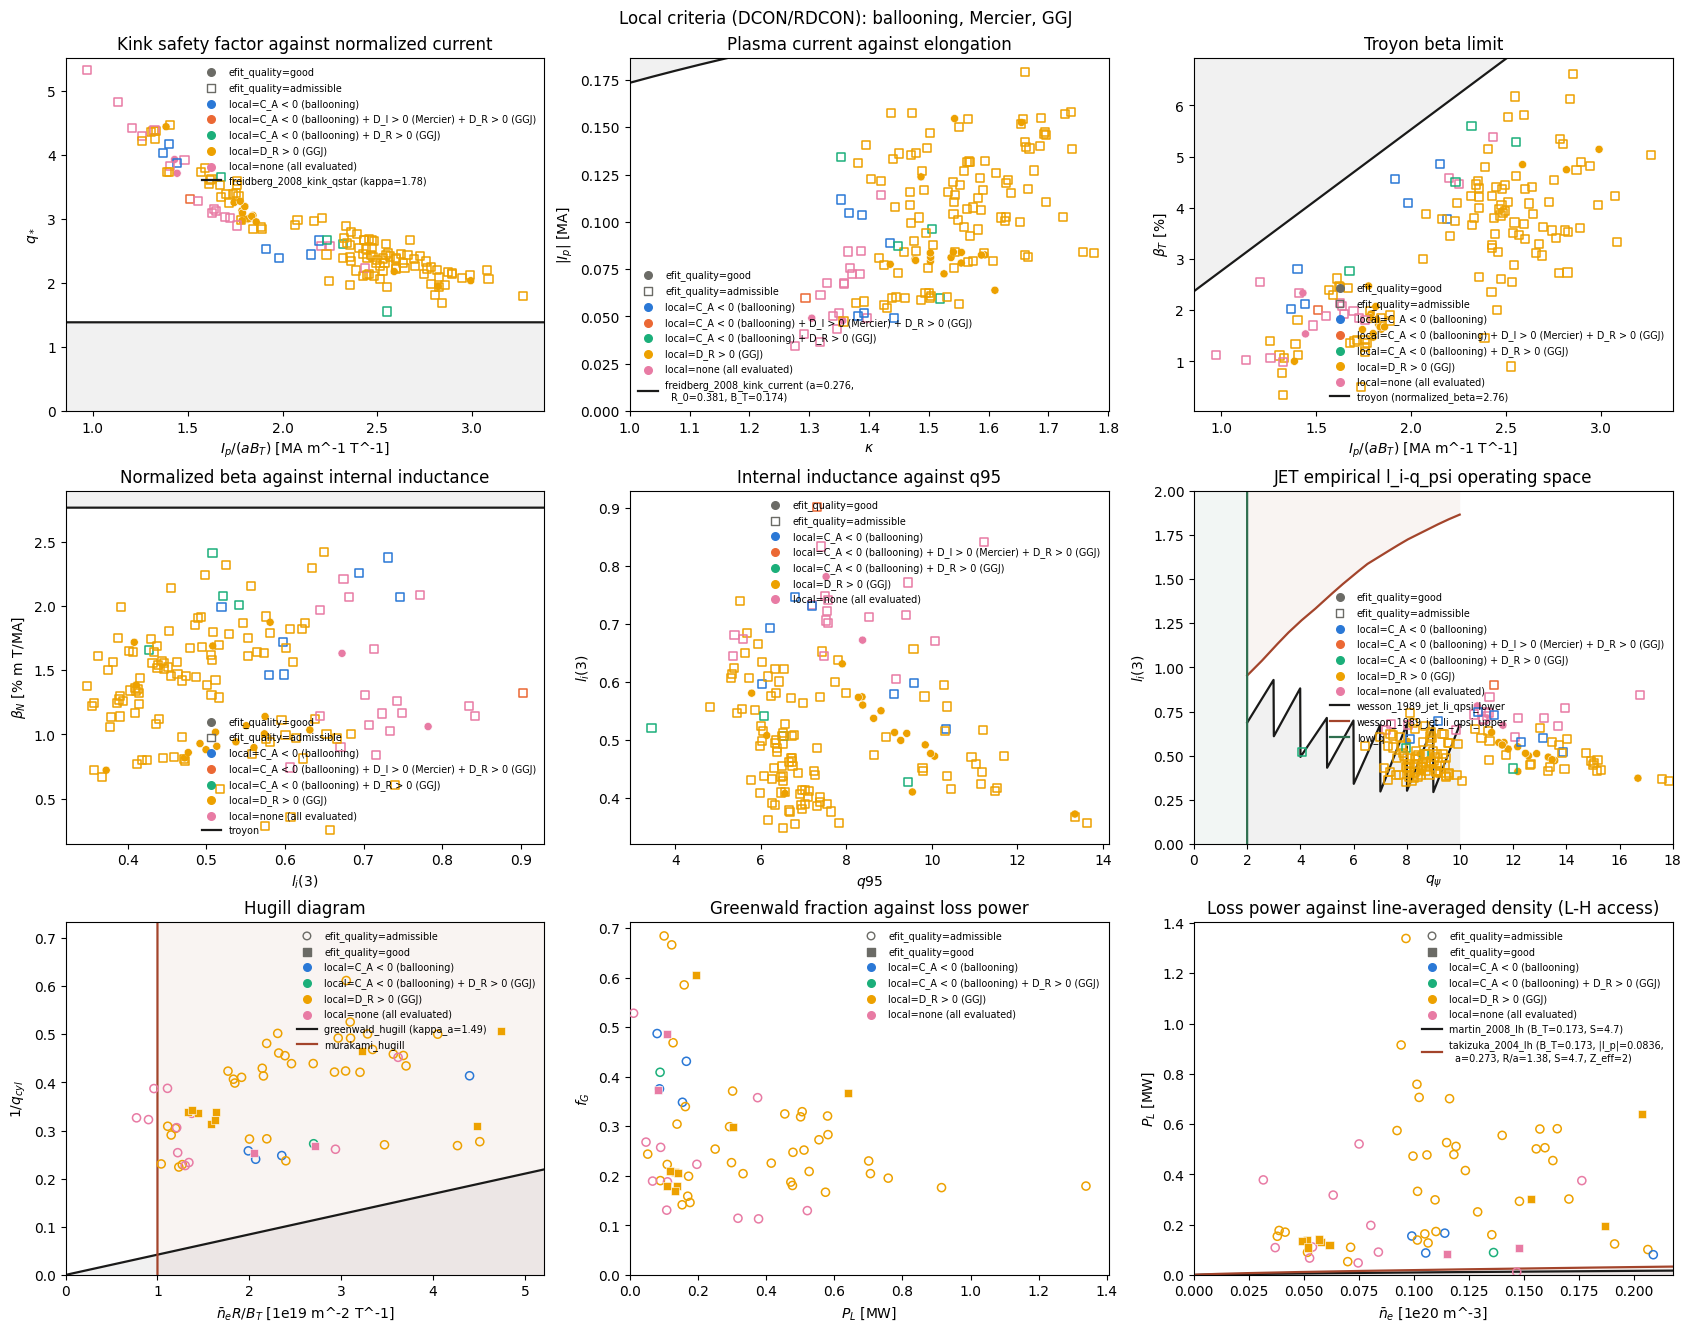

states plotted per plane: {'qstar_in': 150, 'ip_kappa': 150, 'troyon': 150, 'beta_n_li': 150, 'q95_li': 150, 'li_qa_wesson': 150, 'hugill': 64, 'greenwald_fraction_power': 63, 'lh_threshold': 63}
note: boundary 'freidberg_2008_kink_qstar' applies to: tokamak, elongated elliptical cross-section
note: boundary 'freidberg_2008_kink_current' applies to: tokamak, elongated elliptical cross-section
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 62 of 150 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'takizuka_2004_lh' applies to: tokamak including spherical tokamaks


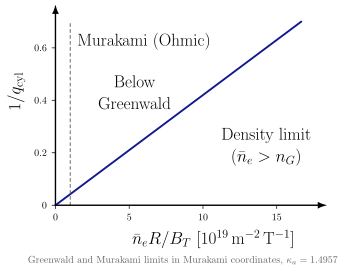

In [ ]:
KAPPA_MAX = float(table["elongation"].clip(upper=2.0).max())   # Freidberg's limit holds for 1 < kappa < 2
PLANES = [("qstar_in", dict(boundary_inputs={"elongation": KAPPA_MAX}, y_range=(0.0, None))),
          ("ip_kappa", dict(x_range=(1.0, None), y_range=(0.0, None))),
          ("troyon", {}), ("beta_n_li", {}), ("q95_li", {}), ("li_qa_wesson", WESSON_SPAN)]
if "murakami_parameter" in table:   # density-limit planes need Lane D's Thomson line average
    # Hugill convention: both axes from the origin, so the Greenwald line through it is visible
    HUGILL_SPAN = dict(x_range=(0.0, 1.1 * float(table["murakami_parameter"].max())),
                       y_range=(0.0, 1.1 * float(table["inverse_cylindrical_q"].max())))
    PLANES += [("hugill", HUGILL_SPAN), ("greenwald_fraction_power", dict(x_range=(0.0, None), y_range=(0.0, None))),
               ("lh_threshold", dict(x_range=(0.0, None), y_range=(0.0, None),
                                     boundary_inputs={"effective_charge": 2.0}))]   # Z_eff = 2, as Lane D assumes
    print("density planes:", int(table["murakami_parameter"].notna().sum()), "states have a Thomson line average;",
          int(table[["greenwald_fraction", "loss_power"]].notna().all(axis=1).sum()), "also have P_loss")


def limits_figure(t, color, title):
    counts = {}
    cols_ = 3
    rows_ = -(-len(PLANES) // cols_)
    fig, axs = plt.subplots(rows_, cols_, figsize=(5.6 * cols_, 4.4 * rows_), constrained_layout=True)
    axs = np.atleast_1d(axs).ravel()
    for ax in axs[len(PLANES):]:
        ax.set_visible(False)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        for ax, (proj, span) in zip(axs, PLANES):
            p = get_projection(proj)
            x, y = p.x.name, p.y.name
            counts[proj] = int((pd.to_numeric(t[x], errors="coerce").notna()
                                & pd.to_numeric(t[y], errors="coerce").notna()).sum()) if x in t and y in t else 0
            operational_space_population(t, proj, color=color, ax=ax, **STYLE, **span)
    fig.suptitle(title)
    plt.show()
    print("states plotted per plane:", counts)
    for message in dict.fromkeys(str(w.message) for w in caught):   # each extrapolation or omission note once
        print("note:", message)


if stab is None:
    print("stability layer: not available")
else:
    # ideal: sign of W_t per n, full edge (truncated edge is in Figure 4)
    for n in sorted(stab["n_tor"].dropna().astype(int).unique()):
        sub = stab[stab["n_tor"] == n].copy()
        sub["ideal"] = ideal_column(sub, "full")
        t = join(table, sub, ["ideal"], f"ideal, n = {n}")
        t["ideal"] = pd.Categorical(t["ideal"].fillna("not available"), categories=IDEAL)
        t.attrs = table.attrs
        limits_figure(t, "ideal", f"Ideal stability, n = {n}: sign of DCON $W_t$ (full edge), mpsi robustness as QA")
    # classical tearing drive: Delta' > 0 at any RDCON rational surface
    if V2 or surf is not None:
        for n in (1, 2):
            drive = drive_frame(stab[stab["n_tor"] == n], n)
            t = join(table, drive, ["tearing_drive"], f"RDCON drive, n = {n}")
            t["tearing_drive"] = pd.Categorical(t["tearing_drive"].fillna("not available"), categories=TEARING)
            t.attrs = table.attrs
            limits_figure(t, "tearing_drive",
                          f"Classical tearing drive, n = {n}: $\\Delta' > 0$ at any RDCON surface (not a tearing verdict)")
    # local criteria: evaluated on the equilibrium, read from the n = 1 rows
    loc = stab[stab["n_tor"] == 1].copy()
    names = {"ballooning_unstable": "C_A < 0 (ballooning)", "ideal_interchange_unstable": "D_I > 0 (Mercier)",
             "resistive_interchange_unstable": "D_R > 0 (GGJ)"}
    present = [c for c in names if c in loc]

    def local_label(row):
        # three states per criterion: unstable, evaluated stable, not evaluated -- never NaN read as stable
        hits = [names[c] for c in present if str(row[c]).lower() in ("true", "1", "1.0")]
        missing = [c for c in present if str(row[c]).lower() not in ("true", "false", "1", "0", "1.0", "0.0")]
        if hits:
            return " + ".join(hits)
        return "not available" if missing or not present else "none (all evaluated)"

    loc["local"] = [local_label(r) for _, r in loc.iterrows()]
    t = join(table, loc, ["local"], "local criteria")
    LOCAL = sorted(set(t["local"].dropna()) - {"none (all evaluated)", "not available"}) + \
        ["none (all evaluated)", "not available"]
    t["local"] = pd.Categorical(t["local"].fillna("not available"), categories=LOCAL)
    t.attrs = table.attrs
    display(t["local"].value_counts().rename("local criteria").to_frame())
    limits_figure(t, "local", "Local criteria (DCON/RDCON): ballooning, Mercier, GGJ")

vaft.diagram.hugill(elongation=float(table["area_elongation"].median()))   # the reference diagram, for comparison

## Provenance

Each layer's `MANIFEST.json` records its inputs (with sha256), the VAFT git sha and the command.
The figures above come only from the tables listed here.

In [ ]:
import json
for manifest in sorted(ATLAS.glob("*/MANIFEST.json")):
    m = json.loads(manifest.read_text())
    print(f"{manifest.parent.name:10s} generated {m.get('generated_at')}  vaft {str(m.get('vaft_git'))[:9]}"
          f"  dirty={m.get('vaft_dirty')}  rows={m.get('rows')}")

confinement generated 2026-10-02T06:25:51.768479+00:00  vaft 48d5e1ae1  dirty=False  rows=133
lane_v     generated 2026-10-02T13:26:08+00:00  vaft 7a6af6901  dirty=False  rows=150
v1         generated 2026-10-01T11:10:52+00:00  vaft 932a90358  dirty=False  rows={'state': 150, 'profiles': 405}
zeff       generated 2026-10-02T06:24:11+00:00  vaft None  dirty=None  rows=None
